In [3]:
from google.colab import files

uploaded = files.upload()

Saving 부산시_행정구별_연도별_폐업수_2023_2025_분석용.csv to 부산시_행정구별_연도별_폐업수_2023_2025_분석용 (1).csv
Saving 부산시_행정구별_월별_방문자수_통합_202301_202606_v2.csv to 부산시_행정구별_월별_방문자수_통합_202301_202606_v2.csv


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr, spearmanr
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

print("라이브러리 불러오기 완료")

라이브러리 불러오기 완료


In [4]:
# 파일 불러오기

# 폐업 데이터
closure = pd.read_csv(
    '부산시_행정구별_연도별_폐업수_2023_2025_분석용 (1).csv',
    encoding='utf-8-sig'
)

# 방문자 데이터
visitor = pd.read_csv(
    '부산시_행정구별_월별_방문자수_통합_202301_202606_v2.csv',
    encoding='utf-8-sig'
)

print("폐업 데이터 크기:", closure.shape)
print("방문자 데이터 크기:", visitor.shape)

폐업 데이터 크기: (48, 3)
방문자 데이터 크기: (672, 6)


In [6]:
# 컬럼 확인

print("===== 폐업 데이터 컬럼 =====")
print(closure.columns.tolist())

print("\n===== 방문자 데이터 컬럼 =====")
print(visitor.columns.tolist())

print("===== 폐업 데이터 =====")
display(closure.head())

print("\n===== 방문자 데이터 =====")
display(visitor.head())

===== 폐업 데이터 컬럼 =====
['연도', '지역명', '폐업수']

===== 방문자 데이터 컬럼 =====
['연월', '행정구', '외국인 방문자 수', '외지인 방문자 수', '현지인 방문자 수', '전체 수']
===== 폐업 데이터 =====


,연도,지역명,폐업수
0,2025,강서구,3850
1,2025,금정구,3365
2,2025,기장군,3200
3,2025,남구,3676
4,2025,동구,2277



===== 방문자 데이터 =====


,연월,행정구,외국인 방문자 수,외지인 방문자 수,현지인 방문자 수,전체 수
0,202301,강서구,116492,3381336,2415172,5913000
1,202301,금정구,11984,2425745,3791823,6229552
2,202301,기장군,44563,3759980,2862748,6667291
3,202301,남구,46794,2470836,4333217,6850847
4,202301,동구,37029,2645570,1401824,4084423


In [7]:
# 방문자 데이터를 연도별로 집계

# 연월에서 연도 추출
visitor['연도'] = visitor['연월'].astype(str).str[:4].astype(int)

# 2023~2025년만 사용
visitor_2023_2025 = visitor[
    visitor['연도'].between(2023, 2025)
].copy()

# 행정구·연도별 관광객 수 합계
visitor_year = (
    visitor_2023_2025
    .groupby(['행정구', '연도'])[
        ['외국인 방문자 수', '외지인 방문자 수', '현지인 방문자 수']
    ]
    .sum()
    .reset_index()
)

print("데이터 크기:", visitor_year.shape)
display(visitor_year.head(10))

데이터 크기: (48, 5)


,행정구,연도,외국인 방문자 수,외지인 방문자 수,현지인 방문자 수
0,강서구,2023,2704399,39971333,30254373
1,강서구,2024,4030043,41067382,30329530
2,강서구,2025,5571300,44556991,33443717
3,금정구,2023,321529,29679346,44717001
4,금정구,2024,386791,29811315,43610259
5,금정구,2025,442505,30955832,43454962
6,기장군,2023,1156329,41591226,35402889
7,기장군,2024,1310556,40585639,35068923
8,기장군,2025,1741118,42224335,37174627
9,남구,2023,1169844,30066424,50914948


In [8]:
# 데이터 개수 확인

print("행 수:", len(visitor_year))
print("행정구 수:", visitor_year['행정구'].nunique())
print("연도 수:", visitor_year['연도'].nunique())

print("\n행정구:")
print(visitor_year['행정구'].unique())

print("\n연도:")
print(visitor_year['연도'].unique())

행 수: 48
행정구 수: 16
연도 수: 3

행정구:
['강서구' '금정구' '기장군' '남구' '동구' '동래구' '부산진구' '북구' '사상구' '사하구' '서구' '수영구'
 '연제구' '영도구' '중구' '해운대구']

연도:
[2023 2024 2025]


In [9]:
#  폐업 데이터와 결합

# 폐업 데이터의 지역명을 행정구로 변경
closure_analysis = closure.rename(
    columns={'지역명': '행정구'}
).copy()

# 방문자 데이터 + 폐업 데이터 결합
analysis = pd.merge(
    visitor_year,
    closure_analysis,
    on=['행정구', '연도'],
    how='inner'
)

print("결합 데이터 크기:", analysis.shape)

display(analysis.head(10))

결합 데이터 크기: (48, 6)


,행정구,연도,외국인 방문자 수,외지인 방문자 수,현지인 방문자 수,폐업수
0,강서구,2023,2704399,39971333,30254373,3755
1,강서구,2024,4030043,41067382,30329530,4123
2,강서구,2025,5571300,44556991,33443717,3850
3,금정구,2023,321529,29679346,44717001,3645
4,금정구,2024,386791,29811315,43610259,3503
5,금정구,2025,442505,30955832,43454962,3365
6,기장군,2023,1156329,41591226,35402889,3429
7,기장군,2024,1310556,40585639,35068923,3421
8,기장군,2025,1741118,42224335,37174627,3200
9,남구,2023,1169844,30066424,50914948,4104


In [10]:
# 확인

print("행정구 수:", analysis['행정구'].nunique())
print("연도 수:", analysis['연도'].nunique())

print("\n결측치")
print(analysis.isnull().sum())

행정구 수: 16
연도 수: 3

결측치
행정구          0
연도           0
외국인 방문자 수    0
외지인 방문자 수    0
현지인 방문자 수    0
폐업수          0
dtype: int64


In [11]:
# H1. 관광객 수는 폐업수와 유의한 관계가 있을것이다.

# 상관분석
# +1에 가까움 → 강한 양의 관계
# 0에 가까움 → 관계가 약함
# -1에 가까움 → 강한 음의 관계

# p-value

# p < 0.05 → 통계적으로 유의한 관계
# p ≥ 0.05 → 통계적으로 유의하다고 판단하기 어려움

visitor_cols = {
    '현지인': '현지인 방문자 수',
    '외지인': '외지인 방문자 수',
    '외국인': '외국인 방문자 수'
}

results = []

for name, col in visitor_cols.items():

    # Pearson 상관분석
    pearson_r, pearson_p = pearsonr(
        analysis[col],
        analysis['폐업수']
    )

    # Spearman 상관분석
    spearman_rho, spearman_p = spearmanr(
        analysis[col],
        analysis['폐업수']
    )

    results.append({
        '관광객 유형': name,
        'Pearson 상관계수': pearson_r,
        'Pearson p-value': pearson_p,
        'Spearman 상관계수': spearman_rho,
        'Spearman p-value': spearman_p
    })

correlation_result = pd.DataFrame(results)

display(correlation_result)

,관광객 유형,Pearson 상관계수,Pearson p-value,Spearman 상관계수,Spearman p-value
0,현지인,0.900003,3.333424e-18,0.725792,5.323027e-09
1,외지인,0.813505,2.111471e-12,0.512592,1.954384e-04
2,외국인,0.183707,2.113424e-01,0.002605,9.859785e-01


In [12]:
# 현지인 관광객 수 → 유의한 관계 있음
# 외지인 관광객 수 → 유의한 관계 있음
# 외국인 관광객 수 → 유의한 관계 없음

# 그리고 중요한 점은 유의한 관계의 방향이 모두 양(+)의 방향이라는 것이다.

In [13]:
# 회귀분석

# 독립변수
X = analysis[
    ['현지인 방문자 수',
     '외지인 방문자 수',
     '외국인 방문자 수']
]

# 종속변수
y = analysis['폐업수']

# 상수항 추가
X = sm.add_constant(X)

# 다중선형회귀
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    폐업수   R-squared:                       0.907
Model:                            OLS   Adj. R-squared:                  0.901
Method:                 Least Squares   F-statistic:                     143.8
Date:                Fri, 14 Aug 2026   Prob (F-statistic):           9.35e-23
Time:                        06:32:01   Log-Likelihood:                -365.95
No. Observations:                  48   AIC:                             739.9
Df Residuals:                      44   BIC:                             747.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4560    204.471      0.002      0.9

In [14]:
# 독립변수
X = analysis[
    ['현지인 방문자 수',
     '외지인 방문자 수',
     '외국인 방문자 수']
]

# 종속변수
y = analysis['폐업수']

# 독립변수 표준화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

# 상수항 추가
X_scaled = sm.add_constant(X_scaled)

# 표준화 회귀
model_scaled = sm.OLS(y, X_scaled).fit()

print(model_scaled.summary())

                            OLS Regression Results                            
Dep. Variable:                    폐업수   R-squared:                       0.907
Model:                            OLS   Adj. R-squared:                  0.901
Method:                 Least Squares   F-statistic:                     143.8
Date:                Fri, 14 Aug 2026   Prob (F-statistic):           9.35e-23
Time:                        06:32:42   Log-Likelihood:                -365.95
No. Observations:                  48   AIC:                             739.9
Df Residuals:                      44   BIC:                             747.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3664.3750     74.661     49.080      0.0

In [15]:
# 회귀모형 전체

# R² = 0.907
# 수정 R² = 0.901
# F-test p-value = 9.35e-23

# 즉, 이 모형은 표본에서 폐업수 변동의 약 90.7%를 세 관광객 수 변수로 설명한다.
# 모형 전체의 p-value도 0.05보다 훨씬 작으므로 세 관광객 수를 이용한 회귀모형 자체는 통계적으로 유의하다.

In [16]:
# 중간 점검

# 상관분석

# 현지인 관광객 수 → 강한 양의 상관관계
# 외지인 관광객 수 → 강한 양의 상관관계
# 외국인 관광객 수 → 유의한 관계 없음

# 다중회귀

# 현지인 관광객 수 → 유의한 양(+)의 관계
# 외지인 관광객 수 → 유의한 양(+)의 관계
# 외국인 관광객 수 → 유의하지 않음

# 따라서 H1의 "관광객 수가 폐업과 유의한 관계가 있다"는 부분은 현지인·외지인에서 확인되고, 외국인에서는 확인되지 않았다.

# 다만 아직 폐업률이 아닌 폐업수를 사용하고 있고, 회귀 결과의 condition number가 1.63e+08로 매우 높기 때문에 다중공선성도 확인해야 한다.

In [17]:
# 독립변수
X = analysis[
    ['현지인 방문자 수',
     '외지인 방문자 수',
     '외국인 방문자 수']
]

# 종속변수
y = analysis['폐업수']

# 독립변수 표준화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

# 상수항 추가
X_scaled = sm.add_constant(X_scaled)

# 표준화 회귀
model_scaled = sm.OLS(y, X_scaled).fit()

print(model_scaled.summary())

                            OLS Regression Results                            
Dep. Variable:                    폐업수   R-squared:                       0.907
Model:                            OLS   Adj. R-squared:                  0.901
Method:                 Least Squares   F-statistic:                     143.8
Date:                Fri, 14 Aug 2026   Prob (F-statistic):           9.35e-23
Time:                        06:40:51   Log-Likelihood:                -365.95
No. Observations:                  48   AIC:                             739.9
Df Residuals:                      44   BIC:                             747.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3664.3750     74.661     49.080      0.0

In [18]:
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

# 사용할 변수
cols = [
    '현지인 방문자 수',
    '외지인 방문자 수',
    '외국인 방문자 수',
    '폐업수'
]

# 전체 변수 표준화
scaler = StandardScaler()

scaled_data = scaler.fit_transform(
    analysis[cols]
)

scaled_analysis = pd.DataFrame(
    scaled_data,
    columns=cols
)

# 독립변수 / 종속변수 분리
X = scaled_analysis[
    ['현지인 방문자 수',
     '외지인 방문자 수',
     '외국인 방문자 수']
]

y = scaled_analysis['폐업수']

# 상수항 추가
X = sm.add_constant(X)

# 회귀분석
model_beta = sm.OLS(y, X).fit()

print(model_beta.summary())

                            OLS Regression Results                            
Dep. Variable:                    폐업수   R-squared:                       0.907
Model:                            OLS   Adj. R-squared:                  0.901
Method:                 Least Squares   F-statistic:                     143.8
Date:                Fri, 14 Aug 2026   Prob (F-statistic):           9.35e-23
Time:                        06:43:29   Log-Likelihood:                -10.988
No. Observations:                  48   AIC:                             29.98
Df Residuals:                      44   BIC:                             37.46
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const               0      0.046          0      1.0

In [19]:
# H1 회귀분석 결과

# 관광객 유형	  표준화 β	      p-value	해석
# 현지인	    +0.6085	< 0.001	 유의한 양의 관계
# 외지인	    +0.4628	< 0.001	 유의한 양의 관계
# 외국인	    -0.0912	0.105	   유의하지 않음

In [20]:
# 다중공선성 검사
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = analysis[
    ['현지인 방문자 수',
     '외지인 방문자 수',
     '외국인 방문자 수']
]

vif_result = pd.DataFrame()

vif_result['변수'] = X_vif.columns
vif_result['VIF'] = [
    variance_inflation_factor(
        X_vif.values,
        i
    )
    for i in range(X_vif.shape[1])
]

display(vif_result)

,변수,VIF
0,현지인 방문자 수,9.215901
1,외지인 방문자 수,14.632177
2,외국인 방문자 수,3.757266


In [21]:
# 변수	                VIF	      판단
# 현지인 관광객 수	  9.216	  매우 높음
# 외지인 관광객 수	  14.632	심각한 다중공선성
# 외국인 관광객 수	  3.757	  허용 가능한 수준

# 특히 외지인 관광객 수 VIF = 14.63이므로, 현지인·외지인 관광객 수가 서로 강하게 겹치는 정보를 가지고 있을 가능성이 높다.

In [22]:
# 현지인, 외지인, 외국인 방문자 수를 각각 폐업수와 회귀분석

import statsmodels.api as sm

visitor_cols = [
    '현지인 방문자 수',
    '외지인 방문자 수',
    '외국인 방문자 수'
]

single_results = []

for col in visitor_cols:

    X = analysis[[col]]
    y = analysis['폐업수']

    X = sm.add_constant(X)

    model = sm.OLS(y, X).fit()

    single_results.append({
        '관광객 유형': col,
        '회귀계수': model.params[col],
        'p-value': model.pvalues[col],
        'R-squared': model.rsquared
    })

single_regression = pd.DataFrame(single_results)

display(single_regression)

,관광객 유형,회귀계수,p-value,R-squared
0,현지인 방문자 수,0.000072,3.333424e-18,0.810006
1,외지인 방문자 수,0.000089,2.111471e-12,0.661791
2,외국인 방문자 수,0.000258,2.113424e-01,0.033748


In [23]:
# 현지인 관광객 수 ↔ 폐업수 : 유의한 관계

# 외지인 관광객 수 ↔ 폐업수 : 유의한 관계

# 외국인 관광객 수 ↔ 폐업수 : 유의한 관계 없음

# 결론

 H1 검증 결과, 현지인 및 외지인 관광객 수는 폐업수와 통계적으로 유의한 양(+)의 관계를 나타냈으며, 외국인 관광객 수는 유의한 관계가 나타나지 않았다. 특히 단순회귀분석에서 현지인 관광객 수의 설명력(R²=0.810)이 외지인 관광객 수(R²=0.662)보다 높게 나타났다. 따라서 관광객 수와 폐업 간의 관계는 관광객 유형에 따라 차이가 있는 것으로 확인되었으며, H1은 부분적으로 지지되었다.

In [29]:
# 시각화 그래프 코딩 전 설정

# 나눔고딕 설치
!apt-get -qq update
!apt-get -qq install fonts-nanum

# Matplotlib 폰트 캐시 삭제
!rm -rf ~/.cache/matplotlib

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 설치된 나눔고딕 확인
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'

# 폰트를 Matplotlib에 직접 등록
fm.fontManager.addfont(font_path)

# 폰트 이름 확인
font_name = fm.FontProperties(fname=font_path).get_name()

print("폰트 이름:", font_name)

# 전역 설정
plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
폰트 이름: NanumGothic


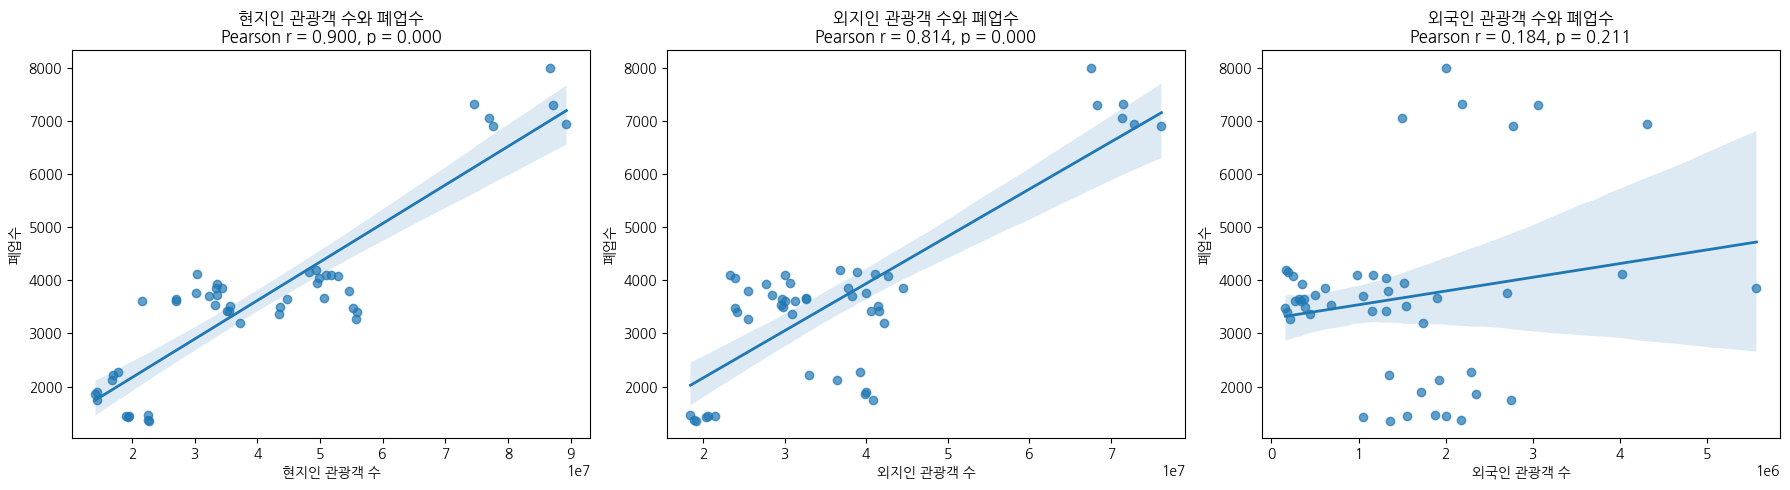

In [33]:
# 관광객 유형별 산점도 + 회귀선 시각화 그래프

# 관광객 수와 폐업수의 관계 방향을 보여줌
# 현지인·외지인은 양의 관계가 뚜렷하고, 외국인은 약함

from scipy.stats import pearsonr

visitor_cols = {
    '현지인': '현지인 방문자 수',
    '외지인': '외지인 방문자 수',
    '외국인': '외국인 방문자 수'
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, col) in zip(axes, visitor_cols.items()):

    sns.regplot(
        data=analysis,
        x=col,
        y='폐업수',
        ax=ax,
        scatter_kws={'alpha': 0.7},
        line_kws={'linewidth': 2}
    )

    # Pearson 상관계수
    r, p = pearsonr(
        analysis[col],
        analysis['폐업수']
    )

    ax.set_title(
        f'{name} 관광객 수와 폐업수\n'
        f'Pearson r = {r:.3f}, p = {p:.3f}'
    )

    ax.set_xlabel(f'{name} 관광객 수')
    ax.set_ylabel('폐업수')

plt.tight_layout()
plt.show()

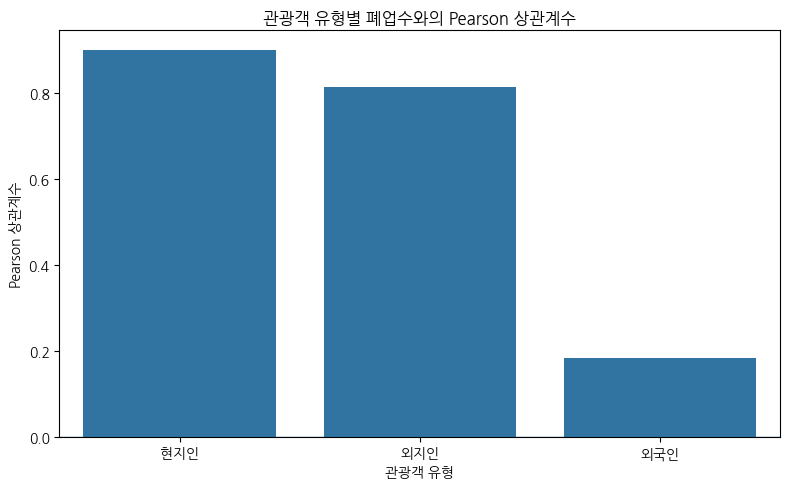

In [31]:
# Pearson 상관계수 비교 그래프

# 현지인 0.900
# 외지인 0.814
# 외국인 0.184
# 관광객 유형별 관계 강도를 직관적으로 비교

plt.figure(figsize=(8, 5))

sns.barplot(
    data=correlation_result,
    x='관광객 유형',
    y='Pearson 상관계수'
)

plt.axhline(
    0,
    linewidth=1
)

plt.title('관광객 유형별 폐업수와의 Pearson 상관계수')
plt.xlabel('관광객 유형')
plt.ylabel('Pearson 상관계수')

plt.tight_layout()
plt.show()

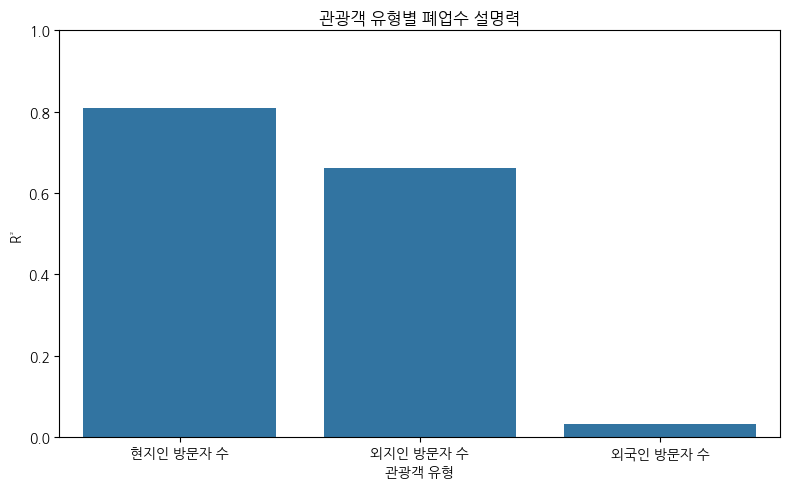

In [32]:
# R^2 비교 그래프

# 현지인 0.810
# 외지인 0.662
# 외국인 0.034
# 각 관광객 수가 폐업수를 얼마나 설명하는지 비교

plt.figure(figsize=(8, 5))

sns.barplot(
    data=single_regression,
    x='관광객 유형',
    y='R-squared'
)

plt.title('관광객 유형별 폐업수 설명력')
plt.xlabel('관광객 유형')
plt.ylabel('R²')

plt.ylim(0, 1)

plt.tight_layout()
plt.show()